<a href="https://colab.research.google.com/github/denverkim/WEBCRAWLING/blob/main/LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MERGE로 데이터 병합

In [1]:
import pandas as pd
left = pd.DataFrame({ 'id':[1,2,3,4,5],
                     'Name': ['Alex', 'Amy', 'Allen', 'Alice', 'Ayoung'],
                     'subject_id':['sub1','sub2','sub4','sub6','sub5']})
right = pd.DataFrame( {'id':[1,2,3,4,5],
                       'Name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty'],
                       'subject_id':['sub2','sub4','sub3','sub6','sub5']})

In [2]:
left

,id,Name,subject_id
0,1,Alex,sub1
1,2,Amy,sub2
2,3,Allen,sub4
3,4,Alice,sub6
4,5,Ayoung,sub5


In [3]:
right

,id,Name,subject_id
0,1,Billy,sub2
1,2,Brian,sub4
2,3,Bran,sub3
3,4,Bryce,sub6
4,5,Betty,sub5


In [4]:
pd.merge(left, right, on='subject_id', how='left')

,id_x,Name_x,subject_id,id_y,Name_y
0,1,Alex,sub1,NaN,NaN
1,2,Amy,sub2,1.0,Billy
2,3,Allen,sub4,2.0,Brian
3,4,Alice,sub6,4.0,Bryce
4,5,Ayoung,sub5,5.0,Betty


In [5]:
pd.merge(left, right, on='subject_id', how='right')

,id_x,Name_x,subject_id,id_y,Name_y
0,2.0,Amy,sub2,1,Billy
1,3.0,Allen,sub4,2,Brian
2,NaN,NaN,sub3,3,Bran
3,4.0,Alice,sub6,4,Bryce
4,5.0,Ayoung,sub5,5,Betty


In [6]:
pd.merge(left, right, on='subject_id', how='outer')

,id_x,Name_x,subject_id,id_y,Name_y
0,1.0,Alex,sub1,NaN,NaN
1,2.0,Amy,sub2,1.0,Billy
2,NaN,NaN,sub3,3.0,Bran
3,3.0,Allen,sub4,2.0,Brian
4,5.0,Ayoung,sub5,5.0,Betty
5,4.0,Alice,sub6,4.0,Bryce


In [7]:
pd.merge(left, right, on='subject_id')

,id_x,Name_x,subject_id,id_y,Name_y
0,2,Amy,sub2,1,Billy
1,3,Allen,sub4,2,Brian
2,4,Alice,sub6,4,Bryce
3,5,Ayoung,sub5,5,Betty


In [8]:
pd.merge(left, right, on=['subject_id', 'id'])

,id,Name_x,subject_id,Name_y
0,4,Alice,sub6,Bryce
1,5,Ayoung,sub5,Betty


# CONCAT으로 데이터 합치기

In [9]:
df1 = pd.DataFrame([['a', 1], ['b', 2]], columns=['letter', 'number'])
df2 = pd.DataFrame([['c', 3], ['d', 4]], columns=['letter', 'number'])

In [10]:
df1

,letter,number
0,a,1
1,b,2


In [11]:
df2

,letter,number
0,c,3
1,d,4


In [12]:
pd.concat([df1, df2]) #위아래로 concat

,letter,number
0,a,1
1,b,2
0,c,3
1,d,4


In [13]:
pd.concat([df1, df2], axis=1) #왼쪽 오른쪽 concat

,letter,number,letter,number
0,a,1,c,3
1,b,2,d,4


# 슬라이드 11번

In [15]:
# 다음 파일을 읽고 데이터 병합을 수행 하시오(https://github.com/sehakflower/data/blob/main/titanic_1309.xlsx?raw=true)
titanic = pd.read_excel('https://github.com/sehakflower/data/blob/main/titanic_1309.xlsx?raw=true')

In [ ]:
# 데이터 붙이기
# 상위 1000행을 train으로 나머지 행을 test로 저장
train = titanic[:1000]
test = titanic[1000:]

# train, test 위아래로 붙이기
pd.concat([train, test])

In [ ]:
# train, test 옆으로 붙이기
pd.concat([train, test], axis=1)

In [30]:
# 데이터 병합
# name, pclass, sex, age를 df1(상위 1000행)으로 name, survived를 df2(하위 500행)로 저장
df1 = titanic[['name', 'pclass', 'sex', 'age']].head(1000)
df2 = titanic[['name', 'survived']].tail(500)

In [32]:
df1

,name,pclass,sex,age
0,"Allen, Miss. Elisabeth Walton",1,female,29.0000
1,"Allison, Master. Hudson Trevor",1,male,0.9167
2,"Allison, Miss. Helen Loraine",1,female,2.0000
3,"Allison, Mr. Hudson Joshua Creighton",1,male,30.0000
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,female,25.0000
...,...,...,...,...
995,"Markoff, Mr. Marin",3,male,35.0000
996,"Markun, Mr. Johann",3,male,33.0000
997,"Masselmani, Mrs. Fatima",3,female,NaN
998,"Matinoff, Mr. Nicola",3,male,NaN


In [33]:
df2

,name,survived
809,"Ford, Mr. Edward Watson",0
810,"Ford, Mr. William Neal",0
811,"Ford, Mrs. Edward (Margaret Ann Watson)",0
812,"Fox, Mr. Patrick",0
813,"Franklin, Mr. Charles (Charles Fardon)",0
...,...,...
1304,"Zabour, Miss. Hileni",0
1305,"Zabour, Miss. Thamine",0
1306,"Zakarian, Mr. Mapriededer",0
1307,"Zakarian, Mr. Ortin",0


In [35]:
# name 으로 inner join
pd.merge(df1, df2, on='name')

,name,pclass,sex,age,survived
0,"Ford, Mr. Edward Watson",3,male,18.0,0
1,"Ford, Mr. William Neal",3,male,16.0,0
2,"Ford, Mrs. Edward (Margaret Ann Watson)",3,female,48.0,0
3,"Fox, Mr. Patrick",3,male,NaN,0
4,"Franklin, Mr. Charles (Charles Fardon)",3,male,NaN,0
...,...,...,...,...,...
188,"Markoff, Mr. Marin",3,male,35.0,0
189,"Markun, Mr. Johann",3,male,33.0,0
190,"Masselmani, Mrs. Fatima",3,female,NaN,1
191,"Matinoff, Mr. Nicola",3,male,NaN,0


In [36]:
# name 으로 outer join
pd.merge(df1, df2, on='name', how='outer')

,name,pclass,sex,age,survived
0,"Abbing, Mr. Anthony",3.0,male,42.0,NaN
1,"Abbott, Master. Eugene Joseph",3.0,male,13.0,NaN
2,"Abbott, Mr. Rossmore Edward",3.0,male,16.0,NaN
3,"Abbott, Mrs. Stanton (Rosa Hunt)",3.0,female,35.0,NaN
4,"Abelseth, Miss. Karen Marie",3.0,female,16.0,NaN
...,...,...,...,...,...
1306,"del Carlo, Mrs. Sebastiano (Argenia Genovesi)",2.0,female,24.0,NaN
1307,"van Billiard, Master. James William",NaN,NaN,NaN,0.0
1308,"van Billiard, Master. Walter John",NaN,NaN,NaN,0.0
1309,"van Billiard, Mr. Austin Blyler",NaN,NaN,NaN,0.0


In [37]:
# name 으로 left join
pd.merge(df1, df2, on='name', how='left')

,name,pclass,sex,age,survived
0,"Allen, Miss. Elisabeth Walton",1,female,29.0000,NaN
1,"Allison, Master. Hudson Trevor",1,male,0.9167,NaN
2,"Allison, Miss. Helen Loraine",1,female,2.0000,NaN
3,"Allison, Mr. Hudson Joshua Creighton",1,male,30.0000,NaN
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,female,25.0000,NaN
...,...,...,...,...,...
997,"Markoff, Mr. Marin",3,male,35.0000,0.0
998,"Markun, Mr. Johann",3,male,33.0000,0.0
999,"Masselmani, Mrs. Fatima",3,female,NaN,1.0
1000,"Matinoff, Mr. Nicola",3,male,NaN,0.0


In [38]:
# name 으로 right join
pd.merge(df1, df2, on='name', how='right')

,name,pclass,sex,age,survived
0,"Ford, Mr. Edward Watson",3.0,male,18.0,0
1,"Ford, Mr. William Neal",3.0,male,16.0,0
2,"Ford, Mrs. Edward (Margaret Ann Watson)",3.0,female,48.0,0
3,"Fox, Mr. Patrick",3.0,male,NaN,0
4,"Franklin, Mr. Charles (Charles Fardon)",3.0,male,NaN,0
...,...,...,...,...,...
497,"Zabour, Miss. Hileni",NaN,NaN,NaN,0
498,"Zabour, Miss. Thamine",NaN,NaN,NaN,0
499,"Zakarian, Mr. Mapriededer",NaN,NaN,NaN,0
500,"Zakarian, Mr. Ortin",NaN,NaN,NaN,0


# 시각화

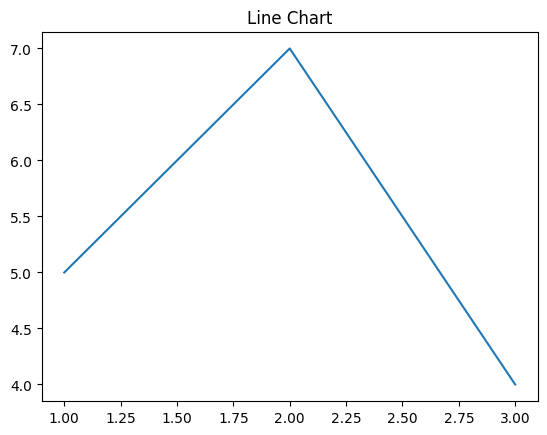

In [42]:
# 선그래프
import matplotlib.pyplot as plt

plt.plot([1,2,3], [5,7,4])
plt.title('Line Chart')
plt.show()

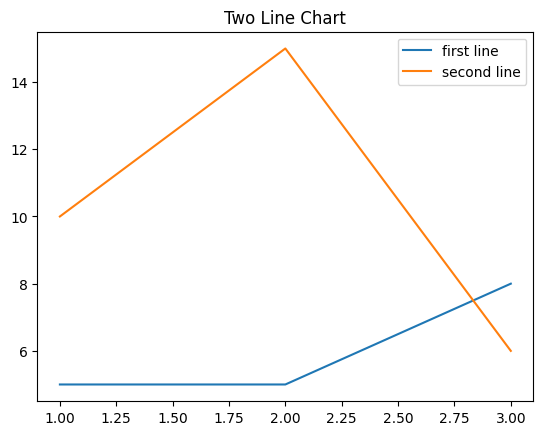

In [46]:
x1 = [1, 2, 3]
y1 = [5, 5, 8]
x2 = [1, 2, 3]
y2 = [10, 15, 6]
plt.plot(x1, y1, label='first line')
plt.plot(x2, y2, label='second line')
plt.legend()
plt.title('Two Line Chart')
plt.show()

<BarContainer object of 5 artists>

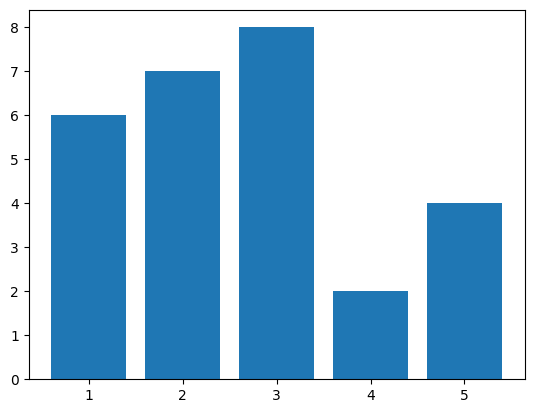

In [48]:
# 막대 그래프
plt.bar([1, 2, 3, 4, 5], [6, 7, 8, 2, 4])

<BarContainer object of 5 artists>

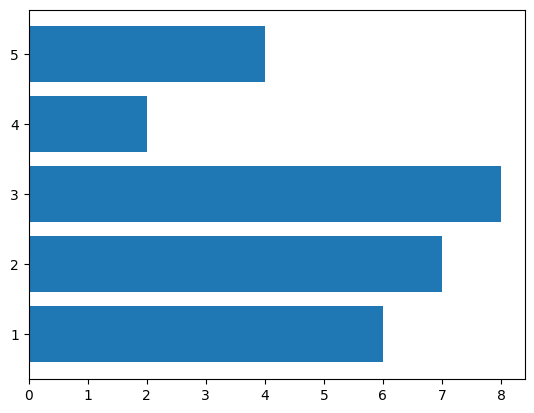

In [51]:
# 수평 막대 그래프
plt.barh([1, 2, 3, 4, 5], [6, 7, 8, 2, 4])

<BarContainer object of 5 artists>

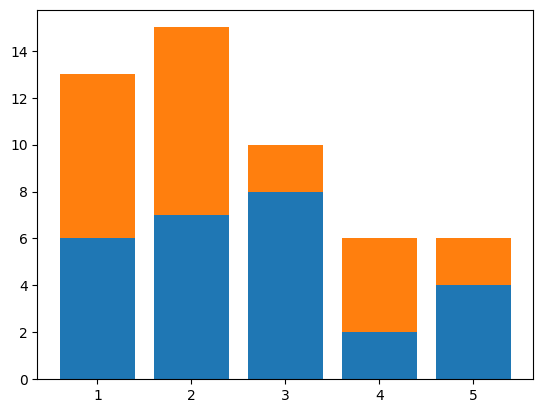

In [54]:
# 누적 막대 그래프
x = [1, 2, 3, 4, 5]
y1 = [6, 7, 8, 2, 4]
y2 = [7, 8, 2, 4, 2]
plt.bar(x, y1)
plt.bar(x, y2, bottom=y1)

<Axes: >

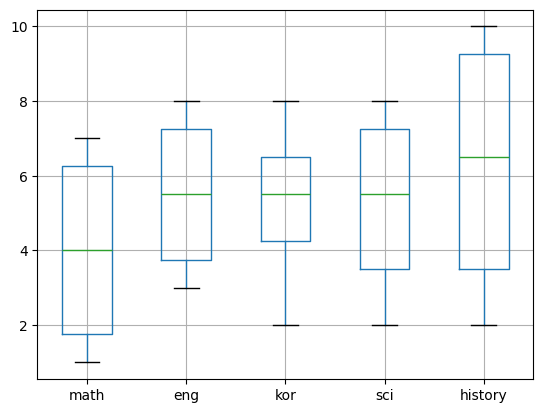

In [58]:
# 박스플랏
data = [[2, 4, 6, 8, 10],[6 ,7, 8, 2, 4],[1, 3, 5, 7, 9],[7, 8, 2, 4, 2]]
df = pd.DataFrame(data)
df.columns = ['math', 'eng', 'kor', 'sci', 'history']
df.boxplot()

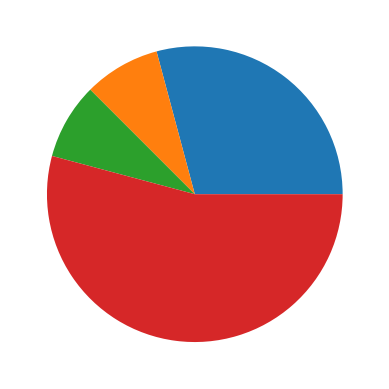

In [60]:
# 파이차트
slices = [7, 2, 2, 13]
activities = ['sleeping','eating','working','playing']
cols = ['c','m','r','k']
plt.pie(slices)
plt.show()

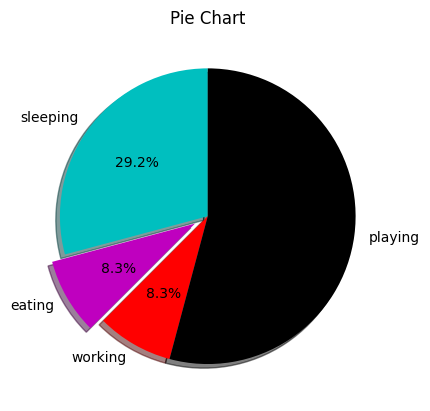

In [61]:
plt.pie(slices,
        labels=activities,
        colors = cols,
        startangle=90,
        shadow=True,
        explode=(0,0.1,0,0),
        autopct='%1.1f%%')
plt.title('Pie Chart')
plt.show()

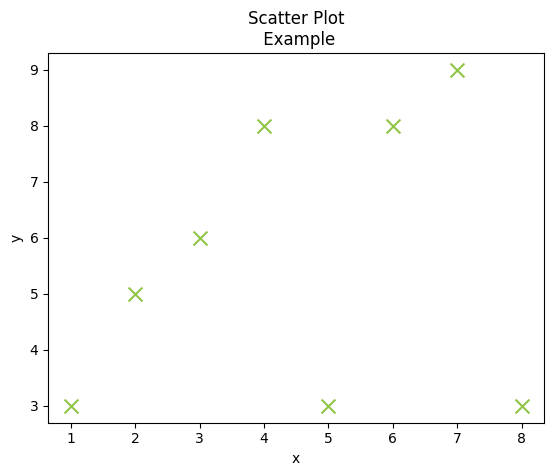

In [67]:
# 산점도
x = [1, 2, 3, 4, 5, 6, 7, 8]
y = [3, 5, 6, 8, 3, 8, 9, 3]
plt.scatter(x,y, color='#90c447', marker='x', s=100)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot\n Example')
plt.show()

In [68]:
# 히트맵
data=[[2,3,4,1],[6,3,5,2],[6,3,5,4],[3,7,5,4],[2,8,1,5]] #5x4 matrix
Index= ['I1', 'I2','I3','I4','I5']
Cols = ['C1', 'C2', 'C3','C4'] #4 variables
df = pd.DataFrame(data, index=Index, columns=Cols)
df

,C1,C2,C3,C4
I1,2,3,4,1
I2,6,3,5,2
I3,6,3,5,4
I4,3,7,5,4
I5,2,8,1,5


In [69]:
df.corr()

,C1,C2,C3,C4
C1,1.000000,-0.597695,0.633866,-0.059391
C2,-0.597695,1.000000,-0.637641,0.745456
C3,0.633866,-0.637641,1.000000,-0.439205
C4,-0.059391,0.745456,-0.439205,1.000000


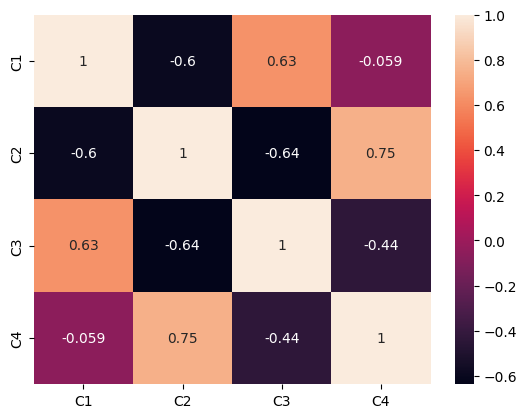

In [73]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)
plt.show()

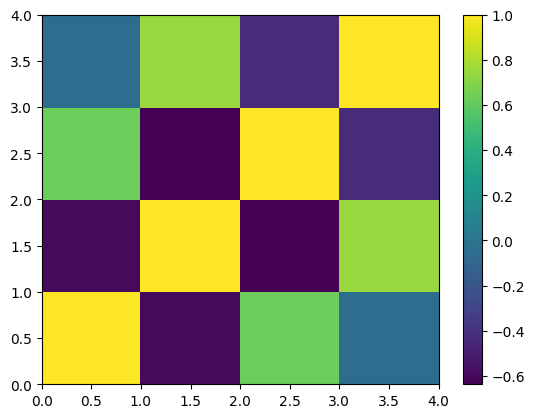

In [72]:
plt.pcolor(df.corr()) #plt.matshow(df.corr())
plt.colorbar()
plt.show()

(array([1., 3., 1., 8., 3., 1., 1., 2., 4., 4.]),
 array([  4. ,  16.6,  29.2,  41.8,  54.4,  67. ,  79.6,  92.2, 104.8,
        117.4, 130. ]),
 <BarContainer object of 10 artists>)

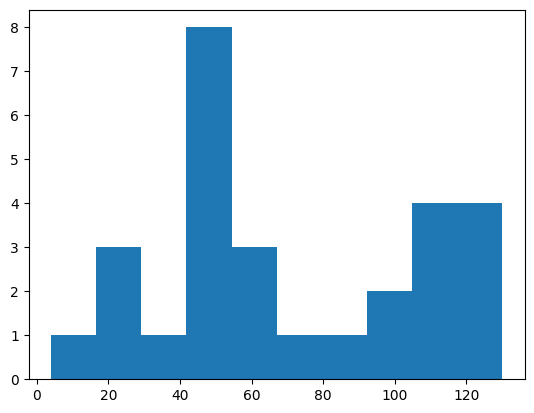

In [74]:
# 히스토그램
population_ages = [22, 55, 62, 45, 21, 22, 34, 42, 42, 4, 99, 102, 110, 120, 121, 122, 130, 111, 115, 112, 80,75, 65, 54, 44, 43, 42, 48]
plt.hist(population_ages)

In [77]:
plt.style.use('ggplot')

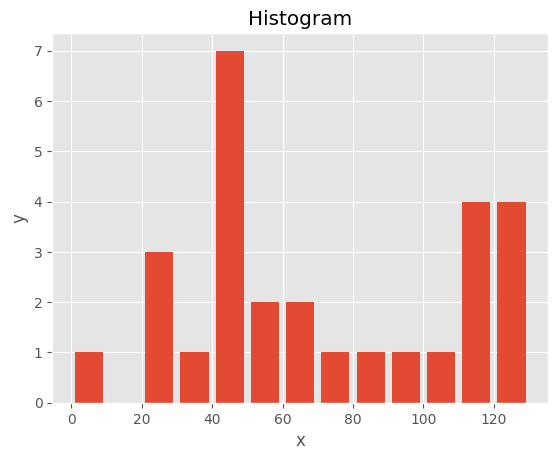

In [78]:
bins = [0, 10, 20, 30, 40 , 50, 60, 70, 80, 90, 100, 110, 120, 130]
plt.hist(population_ages, bins, histtype='bar', rwidth=.8)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Histogram')
plt.show()

In [76]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']